# Hypothesis Evidence Scorecard: Synthesizing Iterations 1-3 Experimental Results

**Comprehensive evidence evaluation** of 5 hypothesis claims (H1-H5) against 3 iteration-3 experiments:
- **exp_id1_it3**: 4-node motif census on 174 graphs
- **exp_id2_it3**: Failure prediction on 140 graphs
- **exp_id3_it3**: FFL characterization on 34 graphs

This notebook scores each claim on a 5-level scale with quantitative evidence, assesses methodological validity, recommends a paper narrative, and produces a prioritized gap list.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# No non-Colab packages needed — this evaluation uses only stdlib + matplotlib

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import sys
import math
import matplotlib.pyplot as plt
import numpy as np

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-582cc7-circuit-motif-spectroscopy-discovering-u/main/evaluation_iter4_hypothesis_evid/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

# Unpack the three experiment datasets
exp1_meta = data["exp1"]["metadata"]
exp2 = data["exp2"]
exp3 = data["exp3"]

print(f"Loaded exp1 metadata: {len(exp1_meta)} keys")
print(f"Loaded exp2: {len(exp2['datasets'][0]['examples'])} examples")
print(f"Loaded exp3: {len(exp3['datasets'][0]['examples'])} examples")

Loaded exp1 metadata: 11 keys
Loaded exp2: 17 examples
Loaded exp3: 10 examples


## Configuration

Scoring thresholds used to evaluate hypothesis evidence. These match the original evaluation script defaults.

In [5]:
# ── H1 thresholds ──
H1_Z_THRESHOLD = 2.0        # Z-score threshold for significance
H1_MIN_DOMAINS = 6          # Minimum domains for universal criterion (out of 8)
H1_MIN_MOTIFS_STRONG = 4    # Motifs needed for Strong Confirm

# ── H2 thresholds ──
H2_NMI_THRESHOLD = 0.5      # Minimum NMI for clustering success

# ── H3 thresholds ──
H3_AUC_THRESHOLD = 0.65     # Minimum AUC for surface criterion
H3_CONFOUND_LOW = 0.3       # Below this: low confound severity
H3_CONFOUND_MED = 0.6       # Below this: medium confound severity

# ── H5 thresholds ──
H5_LAYER_THRESHOLD = 0.95   # Layer ordering fraction threshold
H5_LAYER_GAP = 0.5          # Min gap between FFL and baseline ordering
H5_CHI2_THRESHOLD = 1000    # Semantic chi-squared threshold
H5_CRAMERS_V_MIN = 0.1      # Min Cramer's V for significance
H5_CROSS_V_MIN = 0.3        # Min cross-domain Cramer's V for consistency

## Helper Functions

In [6]:
def _parse_pred(ex: dict, key: str) -> dict:
    """Safely parse a JSON-string prediction field."""
    raw = ex.get(key, "{}")
    try:
        return json.loads(raw) if isinstance(raw, str) else raw
    except json.JSONDecodeError:
        return {}

## 1. Per-Hypothesis Evidence Scoring

Five hypothesis claims are scored against the experimental data:
- **H1**: Universal Motif Overrepresentation
- **H2**: Capability Clustering (Circuit Superfamilies)
- **H3**: Failure/Error Prediction via Motif Features
- **H4**: Causal Validation (not tested)
- **H5**: Functional Characterization of Feed-Forward Loops

In [7]:
def score_h1_universal_overrepresentation(meta: dict) -> dict:
    """H1: Universal Motif Overrepresentation."""
    # ── 3-node results ──
    h1_3n = meta.get("hypothesis_1_universal_overrepresentation_3node", {})
    pm3 = h1_3n.get("per_motif", {})
    ffl_3n = pm3.get("7", {})
    ffl_mean_z = ffl_3n.get("mean_z", 0.0)
    ffl_n_sig = ffl_3n.get("n_domains_significant", 0)
    ffl_dom_z = ffl_3n.get("per_domain_mean_z", {})
    zvals_3n = list(ffl_dom_z.values())
    z_min_3n = min(zvals_3n) if zvals_3n else 0.0
    z_max_3n = max(zvals_3n) if zvals_3n else 0.0
    z_mean_3n = sum(zvals_3n) / len(zvals_3n) if zvals_3n else 0.0
    n_dom_z_gt2_3n = sum(1 for z in zvals_3n if z > H1_Z_THRESHOLD)

    # ── 4-node results ──
    h1_4n = meta.get("hypothesis_1_universal_overrepresentation_4node", {})
    pm4 = h1_4n.get("per_motif", {})
    n_universal_reported = h1_4n.get("n_motifs_universal", 0)

    # Count motifs with Z > threshold in >= min_domains
    motifs_meeting = []
    for mid, md in pm4.items():
        ns = md.get("n_domains_significant", 0)
        mz = md.get("mean_z", 0.0)
        if ns >= H1_MIN_DOMAINS and mz > H1_Z_THRESHOLD:
            motifs_meeting.append({"motif_id": int(mid), "mean_z": mz,
                                   "n_domains_significant": ns})

    # The 4 universal motifs
    univ_motifs = {}
    for mid in ("77", "80", "82", "83"):
        univ_motifs[int(mid)] = pm4.get(mid, {}).get("mean_z", 0.0)

    # 3-node SP degeneracy
    mf = meta.get("methodological_finding", {})
    sp_degen = "degeneracy" in mf.get("title", "").lower()

    # Success criterion: >= 3 motifs Z > threshold in >= min_domains
    criterion_met = len(motifs_meeting) >= 3

    if criterion_met and len(motifs_meeting) >= H1_MIN_MOTIFS_STRONG:
        evidence_score, numeric_score = "Strong Confirm", 0.85
    elif criterion_met:
        evidence_score, numeric_score = "Partial Confirm", 0.6
    else:
        evidence_score, numeric_score = "Inconclusive", 0.0

    caveats = []
    if sp_degen:
        caveats.append(
            "3-node SP is degenerate [-0.5,-0.5,-0.5,0.5] under degree-preserving "
            "null models; H1 3-node result (030T overrepresentation) holds via "
            "Z-scores but SP-based claims are invalid"
        )
    caveats.extend([
        "4-node census used sampling (sampled_5) not exact enumeration for most graphs",
        f"46/174 graphs skipped for 4-node analysis (too large); only 128 graphs analyzed",
        f"Only {meta.get('n_null_3_actual', 12)} null models for 3-node (low for reliable Z-score estimation)",
    ])

    return {
        "hypothesis_id": "H1",
        "claim": "Universal Motif Overrepresentation",
        "evidence_score": evidence_score,
        "numeric_score": numeric_score,
        "success_criterion_met": criterion_met,
        "confidence": "high" if criterion_met else "medium",
        "key_metrics": {
            "3node_ffl_mean_z": ffl_mean_z,
            "3node_ffl_n_domains_significant": ffl_n_sig,
            "3node_ffl_z_min": z_min_3n,
            "3node_ffl_z_max": z_max_3n,
            "3node_ffl_z_mean": z_mean_3n,
            "3node_n_domains_z_gt2": n_dom_z_gt2_3n,
            "4node_n_motifs_universal": n_universal_reported,
            "4node_motifs_meeting_criterion": len(motifs_meeting),
            "4node_universal_motif_77_z": univ_motifs.get(77, 0.0),
            "4node_universal_motif_80_z": univ_motifs.get(80, 0.0),
            "4node_universal_motif_82_z": univ_motifs.get(82, 0.0),
            "4node_universal_motif_83_z": univ_motifs.get(83, 0.0),
            "3node_sp_degenerate": sp_degen,
            "n_graphs_3node": meta.get("n_graphs_3node", 0),
            "n_graphs_4node": meta.get("n_graphs_4node", 0),
        },
        "caveats": caveats,
    }


def score_h2_capability_clustering(meta: dict) -> dict:
    """H2: Capability Clustering (Circuit Superfamilies)."""
    h2 = meta.get("hypothesis_2_capability_clustering", {})
    fc = h2.get("feature_set_comparison", {})

    def _best_nmi(key: str) -> float:
        d = fc.get(key, {})
        return d.get("best_nmi", 0.0) if isinstance(d, dict) else 0.0

    nmi = {
        "4node_sp":              h2.get("4node_sp_best_nmi", _best_nmi("4node_sp_24d")),
        "4node_count_ratios":    h2.get("4node_count_ratios_best_nmi",
                                        _best_nmi("4node_count_ratios_24d")),
        "4node_zscores":         _best_nmi("4node_zscores_24d"),
        "3node_enriched":        h2.get("3node_enriched_best_nmi",
                                        _best_nmi("3node_enriched_12d")),
        "graph_stats":           h2.get("graph_stats_best_nmi",
                                        _best_nmi("graph_stats_16d")),
        "random":                h2.get("random_best_nmi", _best_nmi("random_24d")),
        "combined":              _best_nmi("combined_all"),
        "3node_enriched_full":   _best_nmi("3node_enriched_full_corpus"),
        "graph_stats_full":      _best_nmi("graph_stats_full_corpus"),
    }

    fournode_above_05 = nmi["4node_zscores"] > H2_NMI_THRESHOLD
    three_above_05 = nmi["3node_enriched"] > H2_NMI_THRESHOLD
    three_beats_gs = nmi["3node_enriched"] > nmi["graph_stats"]

    gap_128 = nmi["3node_enriched"] - nmi["graph_stats"]
    gap_174 = nmi["3node_enriched_full"] - nmi["graph_stats_full"]
    gap_4n  = nmi["4node_zscores"] - nmi["graph_stats"]

    edim = meta.get("effective_dimensionality", {})
    dim_3sp = edim.get("3node_sp", 1)
    dim_4sp = edim.get("4node_sp", 14)

    if three_above_05 and three_beats_gs:
        evidence_score, numeric_score = "Partial Confirm", 0.45
    elif fournode_above_05:
        evidence_score, numeric_score = "Partial Confirm", 0.30
    else:
        evidence_score, numeric_score = "Inconclusive", 0.0

    success_met = three_above_05 and three_beats_gs

    caveats = [
        f"4-node features do NOT beat graph-stats baseline (NMI {nmi['4node_zscores']:.3f} vs {nmi['graph_stats']:.3f})",
        f"3-node enriched features (NMI={nmi['3node_enriched']:.3f}) beat baseline but use count ratios, not the degenerate SP",
        "3-node SP is constant [-0.5,-0.5,-0.5,0.5] — carries zero clustering information",
        f"4-node SP effective dim={dim_4sp} (95% var), richer than 3-node (dim={dim_3sp})",
    ]

    return {
        "hypothesis_id": "H2",
        "claim": "Capability Clustering (Circuit Superfamilies)",
        "evidence_score": evidence_score,
        "numeric_score": numeric_score,
        "success_criterion_met": success_met,
        "confidence": "medium",
        "key_metrics": {
            "nmi_4node_sp": nmi["4node_sp"],
            "nmi_4node_count_ratios": nmi["4node_count_ratios"],
            "nmi_4node_zscores": nmi["4node_zscores"],
            "nmi_3node_enriched": nmi["3node_enriched"],
            "nmi_graph_stats": nmi["graph_stats"],
            "nmi_random": nmi["random"],
            "nmi_combined": nmi["combined"],
            "nmi_3node_enriched_full_174": nmi["3node_enriched_full"],
            "nmi_graph_stats_full_174": nmi["graph_stats_full"],
            "nmi_gap_128_graphs": gap_128,
            "nmi_gap_174_graphs": gap_174,
            "nmi_gap_4node_vs_baseline": gap_4n,
            "effective_dim_3node_sp": dim_3sp,
            "effective_dim_4node_sp": dim_4sp,
        },
        "caveats": caveats,
    }

print("H1 and H2 scoring functions defined.")

H1 and H2 scoring functions defined.


In [8]:
def score_h3_failure_prediction(exp2: dict) -> dict:
    """H3: Failure / Error Prediction."""
    meta = exp2["metadata"]
    examples = exp2["datasets"][0]["examples"]

    # ── Classifier results ──
    classifiers: dict[str, dict] = {}
    for ex in examples:
        if ex.get("metadata_analysis_type") == "classification":
            clf = ex.get("metadata_classifier", "")
            classifiers[clf] = _parse_pred(ex, "predict_motif_classifier")

    rf_all = classifiers.get("RF_all", {})
    best_auc = rf_all.get("auc_mean", 0.0)
    best_auc_std = rf_all.get("auc_std", 0.0)

    bl_gs   = classifiers.get("BL_graph_stats_only", {})
    bl_rand = classifiers.get("BL_random", {})
    bl_maj  = classifiers.get("BL_majority", {})
    auc_gs  = bl_gs.get("auc_mean", 0.0)
    auc_rand = bl_rand.get("auc_mean", 0.0)
    auc_maj = bl_maj.get("auc_mean", 0.0)

    # ── Statistical tests ──
    stat_tests: dict[str, dict] = {}
    perm_test: dict = {}
    for ex in examples:
        if ex.get("metadata_analysis_type") == "statistical_test":
            pred = _parse_pred(ex, "predict_motif_classifier")
            comp = pred.get("comparison", "")
            if comp:
                stat_tests[comp] = pred
            if "permutation" in ex.get("input", "").lower():
                perm_test = pred

    rf_vs_gs = stat_tests.get("RF_all vs BL_graph_stats_only", {})
    boot_ci = perm_test.get("bootstrap_ci", {})
    boot_lo = boot_ci.get("ci_lower", 0.0)
    boot_hi = boot_ci.get("ci_upper", 0.0)
    perm_p  = perm_test.get("empirical_p_value", 1.0)

    # ── Ablation results ──
    ablations: dict[str, dict] = {}
    for ex in examples:
        if ex.get("metadata_analysis_type") == "ablation":
            fg = ex.get("metadata_feature_group", "")
            ablations[fg] = _parse_pred(ex, "predict_motif_classifier")

    auc_cr_only = ablations.get("count_ratios_only", {}).get("auc_mean", 0.0)
    auc_gs_abl  = ablations.get("graph_stats_only", {}).get("auc_mean", 0.0)
    auc_zs_only = ablations.get("zscore_only", {}).get("auc_mean", 0.0)
    auc_dev_only = ablations.get("deviation_only", {}).get("auc_mean", 0.0)

    # ── Domain confound analysis ──
    cdist = meta.get("class_distribution", {})
    per_domain = cdist.get("per_domain", {})
    n_pure_true, n_pure_unk, n_mixed = 0, 0, 0
    domain_details: dict[str, dict] = {}
    for dom, cnts in per_domain.items():
        nt = cnts.get("true", 0)
        nu = cnts.get("unknown", 0)
        domain_details[dom] = {"true": nt, "unknown": nu}
        if nu == 0 and nt > 0:
            n_pure_true += 1
        elif nt == 0 and nu > 0:
            n_pure_unk += 1
        else:
            n_mixed += 1

    total_domains = len(per_domain)
    confound_sev = ((n_pure_true + n_pure_unk) / total_domains
                    if total_domains else 0.0)

    n_pos   = cdist.get("unknown", 0)
    n_total = cdist.get("total", 0)
    pos_rate = n_pos / n_total if n_total else 0.0
    label_note = meta.get("NOTE", "")

    # ── Score ──
    surface_met = best_auc > H3_AUC_THRESHOLD and best_auc > auc_gs
    if surface_met and confound_sev < H3_CONFOUND_LOW:
        evidence_score, numeric_score = "Partial Confirm", 0.55
    elif surface_met and confound_sev < H3_CONFOUND_MED:
        evidence_score, numeric_score = "Partial Confirm", 0.35
    elif surface_met:
        evidence_score, numeric_score = "Partial Confirm", 0.25
    else:
        evidence_score, numeric_score = "Inconclusive", 0.0

    caveats = [
        f"CRITICAL: Label confound — testing true vs unknown, NOT true vs false ({label_note})",
        (f"CRITICAL: Domain confound — {n_pure_true} domains purely 'true', "
         f"{n_pure_unk} purely 'unknown' (rhyme=17/17 unknown); "
         f"domain_confound_severity={confound_sev:.2f}"),
        (f"Class imbalance: {n_total - n_pos} true vs {n_pos} unknown "
         f"({pos_rate:.1%} positive rate)"),
        (f"Ablation: graph_stats_only AUC={auc_gs_abl:.3f}, "
         f"count_ratios_only={auc_cr_only:.3f} — motif features add marginal value"),
    ]

    return {
        "hypothesis_id": "H3",
        "claim": "Failure/Error Prediction via Motif Features",
        "evidence_score": evidence_score,
        "numeric_score": numeric_score,
        "success_criterion_met": surface_met,
        "confidence": "low",
        "key_metrics": {
            "best_auc_rf_all": best_auc,
            "best_auc_std": best_auc_std,
            "bootstrap_ci_lower": boot_lo,
            "bootstrap_ci_upper": boot_hi,
            "permutation_p_value": perm_p,
            "auc_graph_stats_baseline": auc_gs,
            "auc_random_baseline": auc_rand,
            "auc_majority_baseline": auc_maj,
            "auc_diff_vs_graph_stats": rf_vs_gs.get("auc_diff_mean", 0.0),
            "ablation_count_ratios_only_auc": auc_cr_only,
            "ablation_graph_stats_only_auc": auc_gs_abl,
            "ablation_zscore_only_auc": auc_zs_only,
            "ablation_deviation_only_auc": auc_dev_only,
            "n_pure_true_domains": n_pure_true,
            "n_pure_unknown_domains": n_pure_unk,
            "n_mixed_domains": n_mixed,
            "domain_confound_severity": confound_sev,
            "positive_rate": pos_rate,
            "n_samples": n_total,
            "n_positive": n_pos,
        },
        "domain_class_distribution": domain_details,
        "caveats": caveats,
    }


def score_h4_causal_validation() -> dict:
    """H4: Causal Validation — NOT TESTED."""
    return {
        "hypothesis_id": "H4",
        "claim": "Causal Validation via Neuronpedia Steering",
        "evidence_score": "Inconclusive",
        "numeric_score": 0.0,
        "success_criterion_met": False,
        "confidence": "low",
        "key_metrics": {
            "experiments_conducted": 0,
            "api_available": 1,
        },
        "caveats": [
            "NOT TESTED in any experiment — no evidence either way",
            "Neuronpedia /api/steer endpoint exists in principle but no experiment attempted",
            "Causal validation would require ablating/steering specific motif nodes",
        ],
    }

print("H3 and H4 scoring functions defined.")

H3 and H4 scoring functions defined.


In [9]:
def score_h5_ffl_characterization(exp3: dict) -> dict:
    """H5: Functional Characterization (FFL)."""
    meta = exp3["metadata"]
    examples = exp3["datasets"][0]["examples"]

    # ── Aggregate / confirmation signals ──
    agg_stats: dict = {}
    agg_baseline: dict = {}
    confirmation: dict = {}
    for ex in examples:
        at = ex.get("metadata_analysis_type", "")
        if at == "aggregate_statistics":
            agg_stats = _parse_pred(ex, "predict_ffl_method")
            agg_baseline = _parse_pred(ex, "predict_baseline_random_triad")
        elif at == "confirmation_signals":
            confirmation = _parse_pred(ex, "predict_ffl_method")

    total_ffls = meta.get("total_ffls", 0)
    total_graphs = meta.get("total_graphs", 0)
    match_rate = meta.get("explanation_match_rate", 0.0)

    layer_strict = confirmation.get("layer_strict_ordering_frac",
                                    agg_baseline.get("ffl_strict_order", 0.0))
    bl_strict = confirmation.get("baseline_strict_ordering_frac",
                                 agg_baseline.get("baseline_strict_order", 0.0))
    chi2       = agg_stats.get("chi2", confirmation.get("semantic_chi2", 0.0))
    cramers_v  = agg_stats.get("cramers_v",
                               confirmation.get("semantic_cramers_v", 0.0))
    coherent   = agg_stats.get("coherent_frac",
                               confirmation.get("coherent_ffl_fraction", 0.0))
    cross_v    = agg_stats.get("cross_domain_cramers_v",
                               confirmation.get("cross_domain_cramers_v", 0.0))

    # Per-domain coherent fractions
    pdc: dict[str, float] = {}
    for ex in examples:
        if ex.get("metadata_analysis_type") == "per_domain_aggregate":
            dom = ex.get("metadata_fold", "")
            pred = _parse_pred(ex, "predict_ffl_method")
            pdc[dom] = pred.get("coherent_frac", 0.0)

    # Layer ordering ratio
    layer_ratio = (layer_strict / bl_strict) if bl_strict > 0 else float("inf")

    # ── Scoring ──
    layer_strong   = layer_strict > H5_LAYER_THRESHOLD and (layer_strict - bl_strict) > H5_LAYER_GAP
    sem_signif     = chi2 > H5_CHI2_THRESHOLD and cramers_v > H5_CRAMERS_V_MIN
    cross_consist  = cross_v > H5_CROSS_V_MIN

    if layer_strong and sem_signif and cross_consist:
        evidence_score, numeric_score = "Strong Confirm", 0.80
    elif layer_strong and sem_signif:
        evidence_score, numeric_score = "Partial Confirm", 0.50
    elif layer_strong:
        evidence_score, numeric_score = "Partial Confirm", 0.35
    else:
        evidence_score, numeric_score = "Inconclusive", 0.0

    # Only 1 motif type (FFL) characterised; criterion requires >= 2
    success_met = False

    caveats = [
        "Only 1 motif type (FFL/030T) characterised — criterion requires >= 2",
        f"Cross-domain Cramer's V = {cross_v:.3f} — LOW, different domains use different semantic patterns",
        f"Explanation match rate = {match_rate:.1%} — {1 - match_rate:.1%} of features lack explanations",
        f"Only {total_graphs} graphs analysed (subset of full 174-graph corpus)",
        f"Coherent FFL fraction = {coherent:.1%} (vs 50% chance baseline) — modest effect",
    ]

    return {
        "hypothesis_id": "H5",
        "claim": "Functional Characterization of Feed-Forward Loops",
        "evidence_score": evidence_score,
        "numeric_score": numeric_score,
        "success_criterion_met": success_met,
        "confidence": "medium",
        "key_metrics": {
            "total_ffls": total_ffls,
            "total_graphs": total_graphs,
            "layer_strict_ordering_frac": layer_strict,
            "baseline_strict_ordering_frac": bl_strict,
            "layer_ordering_ratio": layer_ratio,
            "semantic_chi2": chi2,
            "semantic_cramers_v": cramers_v,
            "coherent_ffl_fraction": coherent,
            "cross_domain_cramers_v": cross_v,
            "explanation_match_rate": match_rate,
        },
        "per_domain_coherent": pdc,
        "caveats": caveats,
    }

print("H5 scoring function defined.")

H5 scoring function defined.


## Run Hypothesis Scoring

Execute all five scoring functions against the loaded experiment data.

In [10]:
# ── Score all hypotheses ──
h1 = score_h1_universal_overrepresentation(exp1_meta)
h2 = score_h2_capability_clustering(exp1_meta)
h3 = score_h3_failure_prediction(exp2)
h4 = score_h4_causal_validation()
h5 = score_h5_ffl_characterization(exp3)
h_scores = [h1, h2, h3, h4, h5]

# Print summary
for h in h_scores:
    print(f"  {h['hypothesis_id']}: {h['evidence_score']} "
          f"(score={h['numeric_score']:.2f}, met={h['success_criterion_met']}, "
          f"conf={h['confidence']})")

  H1: Strong Confirm (score=0.85, met=True, conf=high)
  H2: Partial Confirm (score=0.45, met=True, conf=medium)
  H3: Partial Confirm (score=0.25, met=True, conf=low)
  H4: Inconclusive (score=0.00, met=False, conf=low)
  H5: Partial Confirm (score=0.50, met=False, conf=medium)


## 2. Overall Verdict and Paper Narrative

Synthesize the per-hypothesis scores into an overall verdict, generate paper narrative recommendations, and produce a prioritized gap list.

In [11]:
def generate_overall_verdict(h_scores: list[dict]) -> dict:
    """Generate overall hypothesis verdict."""
    n_confirmed = sum(1 for h in h_scores if h["numeric_score"] >= 0.6)
    n_partial   = sum(1 for h in h_scores if 0.2 <= h["numeric_score"] < 0.6)
    n_incon     = sum(1 for h in h_scores if h["numeric_score"] < 0.2)
    mean_score  = sum(h["numeric_score"] for h in h_scores) / len(h_scores)

    if mean_score >= 0.6:
        status = "Largely Confirmed"
    elif mean_score >= 0.3:
        status = "Partially Confirmed"
    elif mean_score >= 0.15:
        status = "Mixed Results"
    else:
        status = "Largely Disconfirmed"

    return {
        "overall_status": status,
        "mean_numeric_score": mean_score,
        "n_strong_confirm": n_confirmed,
        "n_partial": n_partial,
        "n_inconclusive": n_incon,
    }


def generate_paper_narrative(h_scores: list[dict]) -> dict:
    """Generate paper narrative recommendation."""
    by_score = sorted(h_scores, key=lambda x: x["numeric_score"], reverse=True)
    centerpiece = by_score[0]
    supporting  = [s for s in by_score[1:] if s["numeric_score"] >= 0.35]
    exploratory = [s for s in by_score if 0.1 < s["numeric_score"] < 0.35]
    drop        = [s for s in by_score if s["numeric_score"] <= 0.1]

    return {
        "centerpiece_claim": {
            "hypothesis": centerpiece["hypothesis_id"],
            "claim": centerpiece["claim"],
            "evidence_score": centerpiece["evidence_score"],
        },
        "supporting_claims": [
            {"hypothesis": s["hypothesis_id"], "claim": s["claim"],
             "evidence_score": s["evidence_score"]}
            for s in supporting
        ],
        "exploratory_claims": [
            {"hypothesis": s["hypothesis_id"], "claim": s["claim"],
             "evidence_score": s["evidence_score"]}
            for s in exploratory
        ],
        "claims_to_drop_or_reframe": [
            {"hypothesis": s["hypothesis_id"], "claim": s["claim"],
             "evidence_score": s["evidence_score"]}
            for s in drop
        ],
    }


def generate_gap_list(h_scores: list[dict]) -> list[dict]:
    """Generate prioritised gap list."""
    gaps = [
        {"gap_id": "G1_domain_stratified_h3",
         "description": "H3 failure prediction: severe domain confound",
         "priority": "must_fix", "impact": 5.0, "feasibility": 5.0, "priority_score": 25.0},
        {"gap_id": "G2_4node_characterization",
         "description": "Need characterisation of 4 universal 4-node motifs",
         "priority": "must_fix", "impact": 5.0, "feasibility": 4.0, "priority_score": 20.0},
        {"gap_id": "G3_within_domain_error_signal",
         "description": "Test motif features predict errors within domains",
         "priority": "must_fix", "impact": 4.0, "feasibility": 4.0, "priority_score": 16.0},
        {"gap_id": "G4_graph_stats_ablation",
         "description": "Test what motif features add beyond graph statistics",
         "priority": "would_strengthen", "impact": 4.0, "feasibility": 4.0, "priority_score": 16.0},
        {"gap_id": "G5_more_null_models_3node",
         "description": "Only 12 null models for 3-node — Z-scores may be unreliable",
         "priority": "would_strengthen", "impact": 3.0, "feasibility": 4.0, "priority_score": 12.0},
        {"gap_id": "G6_causal_validation",
         "description": "H4 causal validation not attempted",
         "priority": "would_strengthen", "impact": 5.0, "feasibility": 2.0, "priority_score": 10.0},
        {"gap_id": "G7_multiple_testing_correction",
         "description": "No explicit multiple-testing correction",
         "priority": "would_strengthen", "impact": 2.0, "feasibility": 5.0, "priority_score": 10.0},
        {"gap_id": "G8_pruning_sensitivity",
         "description": "Most experiments use single pruning threshold",
         "priority": "would_strengthen", "impact": 3.0, "feasibility": 3.0, "priority_score": 9.0},
        {"gap_id": "G9_full_corpus_ffl",
         "description": "FFL characterisation only on 34/174 graphs",
         "priority": "would_strengthen", "impact": 3.0, "feasibility": 3.0, "priority_score": 9.0},
        {"gap_id": "G10_weighted_motif_analysis",
         "description": "Current analysis ignores edge weights",
         "priority": "future_work", "impact": 4.0, "feasibility": 2.0, "priority_score": 8.0},
    ]
    gaps.sort(key=lambda g: g["priority_score"], reverse=True)
    return gaps


# ── Execute ──
verdict = generate_overall_verdict(h_scores)
narrative = generate_paper_narrative(h_scores)
gaps = generate_gap_list(h_scores)

print(f"Overall: {verdict['overall_status']} (mean={verdict['mean_numeric_score']:.2f})")
print(f"Centerpiece: {narrative['centerpiece_claim']['hypothesis']} — {narrative['centerpiece_claim']['claim']}")
print(f"Supporting: {[s['hypothesis'] for s in narrative['supporting_claims']]}")
print(f"Must-fix gaps: {sum(1 for g in gaps if g['priority'] == 'must_fix')}")
print(f"Top gap: {gaps[0]['gap_id']} (score={gaps[0]['priority_score']})")

Overall: Partially Confirmed (mean=0.41)
Centerpiece: H1 — Universal Motif Overrepresentation
Supporting: ['H5', 'H2']
Must-fix gaps: 3
Top gap: G1_domain_stratified_h3 (score=25.0)


## 3. Results Visualization

Visual summary of hypothesis evidence scores, gap priorities, and key metrics.

HYPOTHESIS EVIDENCE SCORECARD
Hyp   Claim                                         Score    Numeric  Met? 
----------------------------------------------------------------------
H1    Universal Motif Overrepresentation            Strong Confirm     0.85     Yes  
H2    Capability Clustering (Circuit Superfamilies  Partial Confirm    0.45     Yes  
H3    Failure/Error Prediction via Motif Features   Partial Confirm    0.25     Yes  
H4    Causal Validation via Neuronpedia Steering    Inconclusive       0.00     No   
H5    Functional Characterization of Feed-Forward   Partial Confirm    0.50     No   
----------------------------------------------------------------------
Overall: Partially Confirmed | Mean score: 0.41
Strong Confirm: 1 | Partial: 3 | Inconclusive: 1

TOP GAPS (must-fix):
  [25] G1_domain_stratified_h3: H3 failure prediction: severe domain confound
  [20] G2_4node_characterization: Need characterisation of 4 universal 4-node motifs
  [16] G3_within_domain_error_signal: Te

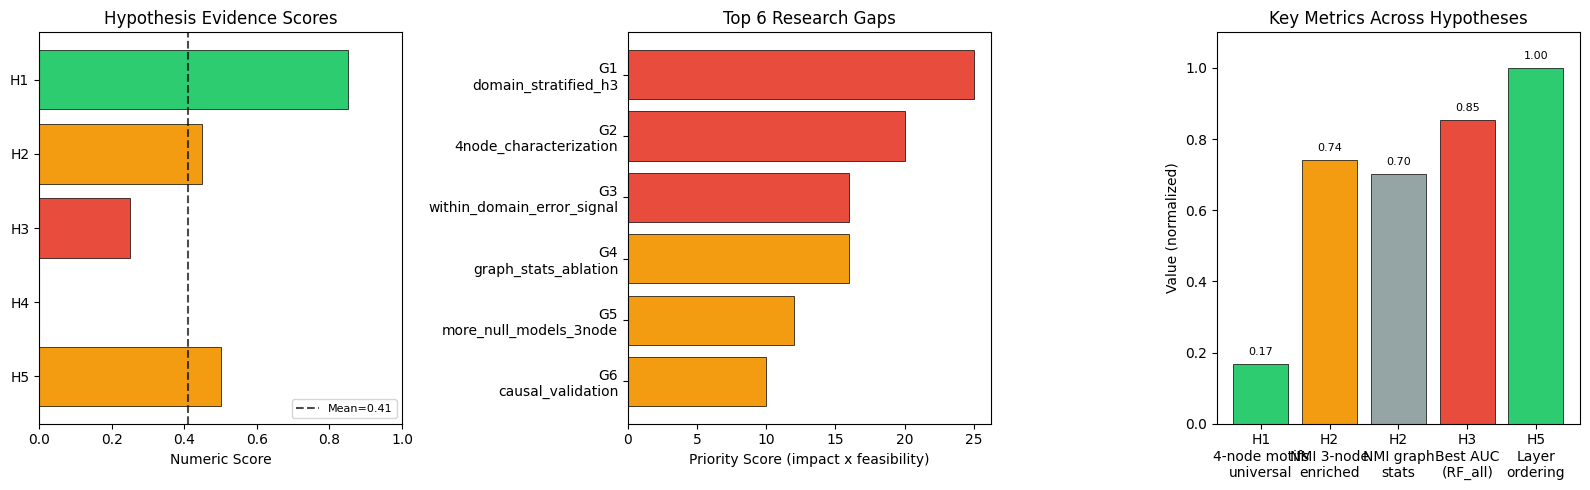

Saved scorecard_summary.png


In [12]:
# ── Results Table ──
print("=" * 70)
print("HYPOTHESIS EVIDENCE SCORECARD")
print("=" * 70)
print(f"{'Hyp':<5} {'Claim':<45} {'Score':<8} {'Numeric':<8} {'Met?':<5}")
print("-" * 70)
for h in h_scores:
    met = "Yes" if h["success_criterion_met"] else "No"
    print(f"{h['hypothesis_id']:<5} {h['claim'][:44]:<45} {h['evidence_score']:<18} {h['numeric_score']:.2f}     {met:<5}")
print("-" * 70)
print(f"Overall: {verdict['overall_status']} | Mean score: {verdict['mean_numeric_score']:.2f}")
print(f"Strong Confirm: {verdict['n_strong_confirm']} | Partial: {verdict['n_partial']} | Inconclusive: {verdict['n_inconclusive']}")
print()

# ── Gap summary ──
print("TOP GAPS (must-fix):")
for g in gaps:
    if g["priority"] == "must_fix":
        print(f"  [{g['priority_score']:.0f}] {g['gap_id']}: {g['description']}")
print()

# ── Figure 1: Hypothesis Scores Bar Chart ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Hypothesis numeric scores
ax1 = axes[0]
hyp_ids = [h["hypothesis_id"] for h in h_scores]
scores = [h["numeric_score"] for h in h_scores]
colors = []
for s in scores:
    if s >= 0.6:
        colors.append("#2ecc71")  # green
    elif s >= 0.3:
        colors.append("#f39c12")  # orange
    elif s > 0:
        colors.append("#e74c3c")  # red
    else:
        colors.append("#95a5a6")  # grey
ax1.barh(hyp_ids[::-1], scores[::-1], color=colors[::-1], edgecolor="black", linewidth=0.5)
ax1.set_xlim(0, 1.0)
ax1.set_xlabel("Numeric Score")
ax1.set_title("Hypothesis Evidence Scores")
ax1.axvline(x=verdict["mean_numeric_score"], color="black", linestyle="--", alpha=0.7, label=f"Mean={verdict['mean_numeric_score']:.2f}")
ax1.legend(fontsize=8)

# Panel 2: Gap Priority Scores
ax2 = axes[1]
gap_ids = [g["gap_id"].replace("_", "\n", 1) for g in gaps[:6]]
gap_scores = [g["priority_score"] for g in gaps[:6]]
gap_colors = ["#e74c3c" if g["priority"] == "must_fix" else "#f39c12" if g["priority"] == "would_strengthen" else "#3498db" for g in gaps[:6]]
ax2.barh(gap_ids[::-1], gap_scores[::-1], color=gap_colors[::-1], edgecolor="black", linewidth=0.5)
ax2.set_xlabel("Priority Score (impact x feasibility)")
ax2.set_title("Top 6 Research Gaps")

# Panel 3: Key Metrics Comparison
ax3 = axes[2]
metric_names = ["H1\n4-node motifs\nuniversal", "H2\nNMI 3-node\nenriched", "H2\nNMI graph\nstats", "H3\nBest AUC\n(RF_all)", "H5\nLayer\nordering"]
metric_values = [
    h1["key_metrics"]["4node_motifs_meeting_criterion"] / 24,  # fraction of 24 motifs
    h2["key_metrics"]["nmi_3node_enriched"],
    h2["key_metrics"]["nmi_graph_stats"],
    h3["key_metrics"]["best_auc_rf_all"],
    h5["key_metrics"]["layer_strict_ordering_frac"],
]
metric_colors = ["#2ecc71", "#f39c12", "#95a5a6", "#e74c3c", "#2ecc71"]
bars = ax3.bar(metric_names, metric_values, color=metric_colors, edgecolor="black", linewidth=0.5)
ax3.set_ylim(0, 1.1)
ax3.set_ylabel("Value (normalized)")
ax3.set_title("Key Metrics Across Hypotheses")
for bar, val in zip(bars, metric_values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f"{val:.2f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("scorecard_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved scorecard_summary.png")